In [12]:
# baselines.ipynb
"""
Four baselines to compare against the MTL model:
# 1. logistic regression (demo + disease flags)
# 2. random forest (demo + disease flags)
# 3. STL neural network (demo + disease flags, no shared trunk)
# 4. MTL no diseases (demo only, shared trunk, no disease flag inputs)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import joblib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split

In [ ]:
# Load everything the same way as always
data = pd.read_csv('saved/nhanes_clean.csv')

with open('saved/col_lists.json', 'r') as f:
    cols = json.load(f)

scaler = joblib.load('saved/demo_scaler.pkl')

demo_cols    = [c for c in cols['demo_cols'] if c not in ['SLQ300', 'SLQ310']]
disease_cols = cols['disease_cols']
disease_meta = cols['disease_meta']
continuous_cols = ['RIDAGEYR','BMXBMI','BMXWAIST','ALQ121','PAQ706','OCQ180','HUQ010','SBP','DBP']
data[continuous_cols] = scaler.transform(data[continuous_cols])

train_df, temp_df = train_test_split(data, test_size=0.30, random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, random_state=42)
print(f'Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# pull architecture constants and circular pairs from checkpoint
checkpoint = torch.load('saved/mtl_model.pt', map_location='cpu')
CIRCULAR_PAIRS = {int(k): v for k, v in checkpoint['circular_pairs'].items()}
K = checkpoint['K']
n_demo = checkpoint['d_demo']
H = checkpoint['H']
dropout = checkpoint['dropout']

Train: 5088, Val: 1090, Test: 1091


In [ ]:
# Baseline 1 and 2 - LR and RF with demo + disease flags
"""
for each disease k, we use all other disease flags as inputs (same as MTL)
so the input is demo_cols + all disease_cols except k + circular
"""

lr_preds = np.full((len(test_df), K), np.nan)
rf_preds = np.full((len(test_df), K), np.nan)

for k, col in enumerate(disease_cols):

    # input features = demo + all other disease flags (exclude target disease)
    other_diseases = [c for i, c in enumerate(disease_cols) 
                  if i != k and i not in CIRCULAR_PAIRS.get(k, [])]
    feature_cols   = demo_cols + other_diseases

    # drop rows where target label or any input disease flag is missing
    train_valid = train_df[col].notna()
    test_valid  = test_df[col].notna()

    X_tr = train_df.loc[train_valid, feature_cols].fillna(0).values.astype(float)
    X_te = test_df.loc[test_valid, feature_cols].fillna(0).values.astype(float)
    y_tr = train_df.loc[train_valid, col].values.astype(float)

    # logistic regression
    """
    Few bits worth mentioning given simplicity of following code:
    (1) BCE is used for the loss function, same as for MTL-NN
    (2) Default sklearn uses L-BFGS to optimise values, hence the iterations, cheaper than Newton, quicker than SGD
    (3) There is an implicit L2 regularisation by default, necessaey in LR.
    """
    lr = LogisticRegression(max_iter=1000, random_state=42) 
    lr.fit(X_tr, y_tr)
    lr_preds[test_valid.values, k] = lr.predict_proba(X_te)[:, 1]

    # random forest
    """
    For RFs:
    (1) No global optimum, instead greedy recursive partioning is used, minimising the Gini impurity.
    (2) Average is taken across 100 trees (n_estimators), to form the RF from the trees
    (3) No max depth set, trying to stay general for baseliness, bagging should help with generalisability
    """
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=1 tries to use all CPU cores simultaenously
    rf.fit(X_tr, y_tr)
    rf_preds[test_valid.values, k] = rf.predict_proba(X_te)[:, 1]

    print(f'  {disease_meta[col]:30s} LR + RF done')

np.save('saved/lr_test_preds.npy', lr_preds)
np.save('saved/rf_test_preds.npy', rf_preds)
print('LR and RF predictions saved')

  Diabetes                       LR + RF done
  Pre-diabetes                   LR + RF done
  Hypertension                   LR + RF done
  High cholesterol               LR + RF done
  Arthritis                      LR + RF done
  Congestive heart failure       LR + RF done
  Coronary heart disease         LR + RF done
  Heart attack                   LR + RF done
  Stroke                         LR + RF done
  Liver condition                LR + RF done
  Thyroid problem                LR + RF done
  COPD/emphysema                 LR + RF done
  Cancer                         LR + RF done
  Kidney disease                 LR + RF done
  Asthma                         LR + RF done
LR and RF predictions saved


In [ ]:
# Baseline 3 - STL neural network, one per disease
"""
Same inputs as LR/RF (demo + other disease flags) but with a single classification task
No shared trunk - each disease is trained completely independently
"""

class STLNet(nn.Module): # Copy and paste from MTL but slight amendments for STL format.
    def __init__(self, n_inputs, H=128, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_inputs, H), nn.BatchNorm1d(H), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(H, H),        nn.BatchNorm1d(H), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(H, 1),        nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

class STLDataset(Dataset):
    def __init__(self, X, y):
        # mask NaNs in y - only train on valid labels
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

stl_preds = np.full((len(test_df), K), np.nan)

for k, col in enumerate(disease_cols):

    other_diseases = [c for i, c in enumerate(disease_cols) 
                  if i != k and i not in CIRCULAR_PAIRS.get(k, [])]
    feature_cols = demo_cols + other_diseases
    n_inputs = len(feature_cols)

    train_valid = train_df[col].notna()
    test_valid = test_df[col].notna()

    X_tr = train_df.loc[train_valid, feature_cols].fillna(0).values.astype(float)
    X_te = test_df.loc[test_valid,   feature_cols].fillna(0).values.astype(float)
    y_tr = train_df.loc[train_valid, col].values.astype(float)

    # train STL net for this disease
    stl_model = STLNet(n_inputs).to(device)
    optimizer = torch.optim.Adam(stl_model.parameters(), lr=1e-3)
    criterion = nn.BCELoss()
    loader = DataLoader(STLDataset(X_tr, y_tr), batch_size=64, shuffle=True)

    # train for 50 epochs, no early stopping to keep it simple - this is usuallt where the MTL stopped learning
    stl_model.train()
    for epoch in range(50):
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            preds = stl_model(X_batch.to(device)).squeeze()
            loss  = criterion(preds, y_batch.to(device))
            loss.backward()
            optimizer.step()

    # get test predictions
    stl_model.eval()
    with torch.no_grad():
        X_te_t = torch.tensor(X_te, dtype=torch.float32).to(device)
        stl_preds[test_valid.values, k] = stl_model(X_te_t).cpu().numpy().squeeze()

    print(f'  {disease_meta[col]:30s} STL done')

np.save('saved/stl_test_preds.npy', stl_preds)
print('STL predictions saved')

  Diabetes                       STL done
  Pre-diabetes                   STL done
  Hypertension                   STL done
  High cholesterol               STL done
  Arthritis                      STL done
  Congestive heart failure       STL done
  Coronary heart disease         STL done
  Heart attack                   STL done
  Stroke                         STL done
  Liver condition                STL done
  Thyroid problem                STL done
  COPD/emphysema                 STL done
  Cancer                         STL done
  Kidney disease                 STL done
  Asthma                         STL done
STL predictions saved


In [ ]:
# Baseline 4 - MTL without disease flags
"""
Same architecture as the main model but disease flags are zeroed out
Isolates the value of disease inputs specifically
"""

# reload the MTL architecture
checkpoint = torch.load('saved/mtl_model.pt', map_location=device)

class MaskedMTLNet(nn.Module):
    def __init__(self, d_demo, K, H=128, dropout=0.3, circular_pairs=None):
        super().__init__()
        self.K = K
        self.circular_pairs = circular_pairs or {}
        self.trunk = nn.Sequential(
            nn.Linear(d_demo, H), nn.BatchNorm1d(H), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(H, H), nn.BatchNorm1d(H), nn.ReLU(), nn.Dropout(dropout),
        )
        self.heads = nn.ModuleList()
        for k in range(K):
            n_masked = 1 + len(self.circular_pairs.get(k, []))
            self.heads.append(nn.Sequential(
                nn.Linear(H + (K - n_masked), H // 2), nn.ReLU(),
                nn.Linear(H // 2, 1), nn.Sigmoid()
            ))

    def forward(self, x_demo, d):
        h = self.trunk(x_demo)
        preds = []
        for k in range(self.K):
            exclude = {k} | set(self.circular_pairs.get(k, []))
            keep = [j for j in range(self.K) if j not in exclude]
            d_input = torch.nan_to_num(d[:, keep].clone(), nan=0.0)
            preds.append(self.heads[k](torch.cat([h, d_input], dim=1)))
        return torch.cat(preds, dim=1)

# retrain MTL from scratch with disease flags zeroed out during training
mtl_nodis = MaskedMTLNet(
    d_demo=checkpoint['d_demo'], K=checkpoint['K'],
    H=checkpoint['H'], dropout=checkpoint['dropout'],
    circular_pairs=checkpoint['circular_pairs']
).to(device)

class NHANESDataset(Dataset):
    def __init__(self, df, demo_cols, disease_cols):
        self.X = torch.tensor(df[demo_cols].values.astype(float), dtype=torch.float32)
        self.D = torch.tensor(df[disease_cols].values.astype(float), dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.D[idx]

train_loader = DataLoader(NHANESDataset(train_df, demo_cols, disease_cols),
                          batch_size=64, shuffle=True)
test_loader  = DataLoader(NHANESDataset(test_df,  demo_cols, disease_cols),
                          batch_size=64, shuffle=False)

optimizer = torch.optim.Adam(mtl_nodis.parameters(), lr=1e-3)
criterion = nn.BCELoss(reduction='none')

# train for 100 epochs with disease flags zeroed out
for epoch in range(100):
    mtl_nodis.train()
    for x_demo, d in train_loader:
        x_demo = x_demo.to(device)
        d      = d.to(device)

        # zero out all disease flags - model only sees demographics
        d_zeroed = torch.zeros_like(d)

        optimizer.zero_grad()
        preds = mtl_nodis(x_demo, d_zeroed)

        # NaN mask per head
        valid_mask = ~torch.isnan(d)
        loss = criterion(preds, torch.nan_to_num(d, nan=0.0))
        loss = (loss * valid_mask).sum() / valid_mask.sum()
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'  epoch {epoch+1}/100 done')

# get test predictions with disease flags zeroed out
mtl_nodis.eval()
mtl_nodis_preds = []
with torch.no_grad():
    for x_demo, d in test_loader:
        d_zeroed = torch.zeros_like(d)
        preds    = mtl_nodis(x_demo.to(device), d_zeroed)
        mtl_nodis_preds.append(preds.cpu().numpy())

mtl_nodis_preds = np.concatenate(mtl_nodis_preds, axis=0)
np.save('saved/mtl_nodis_test_preds.npy', mtl_nodis_preds)
print('MTL no-disease predictions saved')

  epoch 10/100 done
  epoch 20/100 done
  epoch 30/100 done
  epoch 40/100 done
  epoch 50/100 done
  epoch 60/100 done
  epoch 70/100 done
  epoch 80/100 done
  epoch 90/100 done
  epoch 100/100 done
MTL no-disease predictions saved


In [ ]:
# Final comparison table - all 5 models
mtl_preds = np.load('saved/mtl_test_preds.npy')
test_targets = np.load('saved/mtl_test_targets.npy')

models = {
    'LR': lr_preds,
    'RF': rf_preds,
    'STL NN': stl_preds,
    'MTL no dis': mtl_nodis_preds,
    'MTL': mtl_preds,
}

header = f"{'Disease':28s}" + ''.join(f"  {n:>10}" for n in models) + '  MTL vs best'
print(header)
print('-' * (28 + 12 * len(models) + 14))

macro = {n: [] for n in models}

for k, col in enumerate(disease_cols):
    valid = ~np.isnan(test_targets[:, k])
    t = test_targets[valid, k]
    row = f"  {disease_meta[col]:28s}"

    aurocs = {}
    for name, preds in models.items():
        a = roc_auc_score(t, preds[valid, k])
        aurocs[name] = a
        macro[name].append(a)

    # best baseline = best model excluding MTL itself
    best_baseline = max(v for k2, v in aurocs.items() if k2 != 'MTL')
    mtl_diff = aurocs['MTL'] - best_baseline

    for name, a in aurocs.items():
        flag = '*' if name == 'MTL' and mtl_diff > 0 else ' '
        row += f"  {a:.3f}{flag}    "

    # show MTL gain vs best baseline, + means MTL wins
    row += f"  {mtl_diff:+.3f}"
    print(row)

print('-' * (28 + 12 * len(models) + 14))
macro_row = f"  {'Macro average':28s}"
for name in models:
    macro_row += f"  {np.mean(macro[name]):.3f}     "

# macro MTL gain vs macro best baseline per disease
macro_diff = np.mean(macro['MTL']) - np.mean([max(macro[n][k] for n in models if n != 'MTL')
                                               for k in range(len(disease_cols))])
macro_row += f"  {macro_diff:+.3f}"
print(macro_row)

Disease                               LR          RF      STL NN  MTL no dis         MTL  MTL vs best
------------------------------------------------------------------------------------------------------
  Diabetes                      0.884       0.878       0.846       0.842       0.879       -0.005
  Pre-diabetes                  0.783       0.781       0.738       0.749       0.804*      +0.021
  Hypertension                  0.861       0.852       0.846       0.824       0.858       -0.003
  High cholesterol              0.818       0.812       0.806       0.769       0.819*      +0.002
  Arthritis                     0.820       0.798       0.790       0.794       0.817       -0.003
  Congestive heart failure      0.939       0.905       0.856       0.875       0.939*      +0.001
  Coronary heart disease        0.896       0.904       0.833       0.814       0.884       -0.020
  Heart attack                  0.872       0.875       0.800       0.807       0.837       -0.037
  S

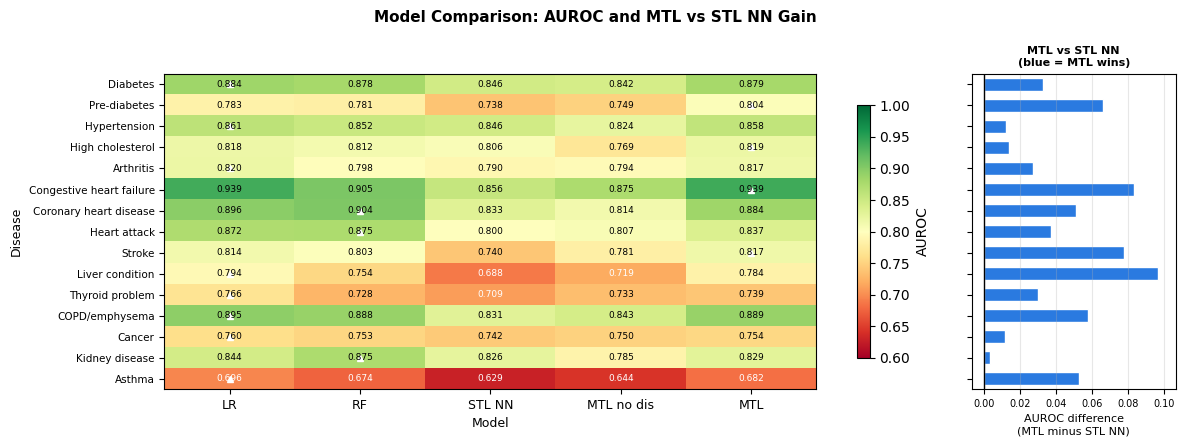

In [ ]:
# combined chart - AUROC heatmap with MTL vs STL delta bars on the right
from sklearn.metrics import roc_auc_score

# load all saved predictions
models = {
    'LR':          np.load('saved/lr_test_preds.npy'),
    'RF':          np.load('saved/rf_test_preds.npy'),
    'STL NN':      np.load('saved/stl_test_preds.npy'),
    'MTL no dis':  np.load('saved/mtl_nodis_test_preds.npy'),
    'MTL':         np.load('saved/mtl_test_preds.npy'),
}
targets = np.load('saved/mtl_test_targets.npy')  # shape (N, 15)

model_names = list(models.keys())
K = len(disease_cols)

# build AUROC matrix: shape (K, n_models)
auroc_matrix = np.zeros((K, len(model_names)))

for j, (name, preds) in enumerate(models.items()):
    for k in range(K):
        valid = ~np.isnan(targets[:, k])
        t = targets[valid, k]
        p = preds[valid, k]
        if t.sum() > 0:
            auroc_matrix[k, j] = roc_auc_score(t, p)

disease_names = [disease_meta[col] for col in disease_cols]
stl_idx = list(models.keys()).index('STL NN')
mtl_idx = list(models.keys()).index('MTL')
deltas = auroc_matrix[:, mtl_idx] - auroc_matrix[:, stl_idx]
colours = ['#2a7ae0' if d > 0 else '#e05c2a' for d in deltas]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5),
                                gridspec_kw={'width_ratios': [4, 1]})

# left - AUROC heatmap
im = ax1.imshow(auroc_matrix, cmap='RdYlGn', aspect='auto', vmin=0.6, vmax=1.0)

ax1.set_xticks(range(len(model_names)))
ax1.set_xticklabels(model_names, fontsize=9)
ax1.set_yticks(range(K))
ax1.set_yticklabels(disease_names, fontsize=7.5)
ax1.set_xlabel('Model', fontsize=9)
ax1.set_ylabel('Disease', fontsize=9)

for i in range(K):
    for j in range(len(model_names)):
        v = auroc_matrix[i, j]
        col = 'white' if v < 0.72 else 'black'
        ax1.text(j, i, f'{v:.3f}', ha='center', va='center',
                 fontsize=6.5, color=col)
    best_j = np.argmax(auroc_matrix[i, :])
    ax1.plot(best_j, i, 'w^', markersize=5)

plt.colorbar(im, ax=ax1, label='AUROC', shrink=0.8)

# right - delta bars, symmetric x axis so negatives show clearly
ax2.barh(range(K), deltas, color=colours, edgecolor='white', height=0.6)
ax2.axvline(0, color='black', lw=1)
ax2.set_yticks(range(K))
ax2.set_yticklabels([])
ax2.set_xlabel('AUROC difference\n(MTL minus STL NN)', fontsize=8)
ax2.set_title('MTL vs STL NN\n(blue = MTL wins)', fontsize=8, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.tick_params(labelsize=7)
ax2.set_ylim(ax1.get_ylim())

# symmetric x axis centred on zero
max_delta = max(abs(deltas))
# set x axis based on actual data range with small padding
ax2.set_xlim(min(deltas) - 0.01, max(deltas) + 0.01)

plt.suptitle('Model Comparison: AUROC and MTL vs STL NN Gain',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('saved/results_combined.png', dpi=150, bbox_inches='tight')
plt.show()

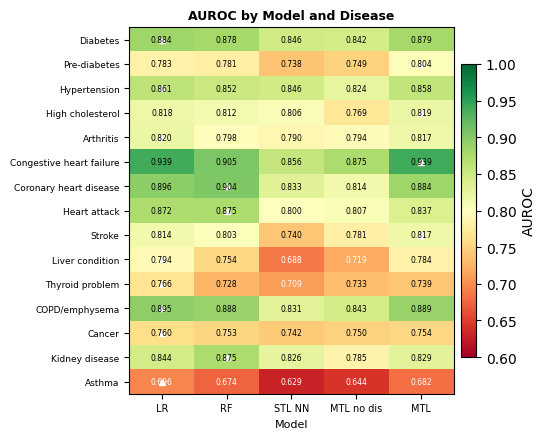

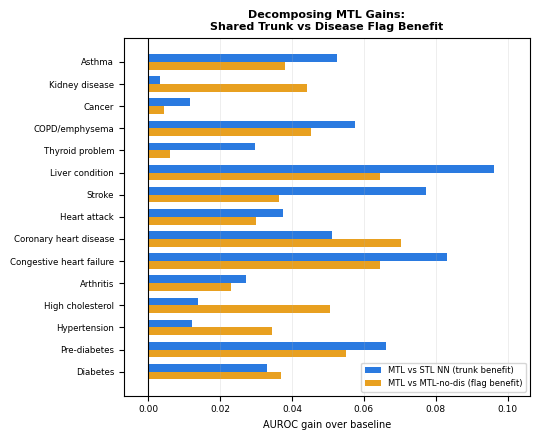

In [ ]:
# Separating the above charts as switching to two column NeurIPS format
fig1, ax1 = plt.subplots(figsize=(5.5, 4.5)) # narrower for single column

im = ax1.imshow(auroc_matrix, cmap='RdYlGn', aspect='auto', vmin=0.6, vmax=1.0) # red=low green=high, anchored 0.6-1.0
ax1.set_xticks(range(len(model_names)))
ax1.set_xticklabels(model_names, fontsize=7) # smaller font fits narrow width
ax1.set_yticks(range(K))
ax1.set_yticklabels(disease_names, fontsize=6.5)
ax1.set_xlabel('Model', fontsize=8)

for i in range(K): # rows = diseases
    for j in range(len(model_names)): # cols = models
        v = auroc_matrix[i, j]
        col = 'white' if v < 0.72 else 'black' # white text on dark red cells
        ax1.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=5.5, color=col)
    best_j = np.argmax(auroc_matrix[i, :]) # best model for this disease
    ax1.plot(best_j, i, 'w^', markersize=4) # white triangle marks winner

plt.colorbar(im, ax=ax1, label='AUROC', shrink=0.8, pad=0.02)
ax1.set_title('AUROC by Model and Disease', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('saved/auroc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

nodis_idx = list(models.keys()).index('MTL no dis')
delta_stl   = auroc_matrix[:, mtl_idx] - auroc_matrix[:, stl_idx] # trunk benefit: MTL vs independent STL
delta_nodis = auroc_matrix[:, mtl_idx] - auroc_matrix[:, nodis_idx] # flag benefit: MTL vs no disease input

fig, ax = plt.subplots(figsize=(5.5, 4.5))

y = np.arange(K)
h = 0.35 # bar height for each group

bars1 = ax.barh(y + h/2, delta_stl,   height=h, color='#2a7ae0', label='MTL vs STL NN (trunk benefit)')
bars2 = ax.barh(y - h/2, delta_nodis, height=h, color='#e8a020', label='MTL vs MTL-no-dis (flag benefit)')

# colour bars red where MTL loses
for bar, d in zip(bars1, delta_stl):
    if d < 0:
        bar.set_color('#e05c2a')
for bar, d in zip(bars2, delta_nodis):
    if d < 0:
        bar.set_color('#e05c2a')

ax.axvline(0, color='black', lw=0.8) # zero line
ax.set_yticks(y)
ax.set_yticklabels(disease_names, fontsize=6.2) # disease names as row labels
ax.set_xlabel('AUROC gain over baseline', fontsize=7)
ax.set_title('Decomposing MTL Gains:\nShared Trunk vs Disease Flag Benefit', fontsize=8, fontweight='bold')
ax.legend(fontsize=6, loc='lower right', framealpha=0.8)
ax.grid(axis='x', alpha=0.3, lw=0.5)
ax.tick_params(axis='x', labelsize=6.5)
ax.set_xlim(min(min(delta_stl), min(delta_nodis)) - 0.01,
            max(max(delta_stl), max(delta_nodis)) + 0.01)

plt.tight_layout()
plt.savefig('saved/auroc_deltas.png', dpi=150, bbox_inches='tight')
plt.show()